# Задание 3

# Нейронный Оператор Фурье

Тонишева Ольга, вариант 4

PDE: Burgers Data: burgers_xt
Research: сходимость в зависимости от числа гармоник R


In [1]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.1 MB/s eta 0:00:00


In [2]:
!pip install neuraloperator==1.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 115.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.9/186.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 128.0 MB/s eta 0:00:00
  Created wheel for torch-harmonics: filename=torch_harmonics-0.7.3-py3-none-any.whl size=87748 sha256=4dcae325914a8b18a18c035f2bab5bec100269f038567ddba4b8299c55b9fc71
  Stored in directory: /root/.cache/pip/wheels/53/e5/23/5dd311b49596ed8933fba1240082719666e03b07e148f90234
Successfully built torch-harmonic

In [3]:
import os
import numpy as np

import torch
import matplotlib.pyplot as plt

import neuralop

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda'

**Software:**

In [4]:
print("neuralop v" + neuralop.__version__)
print("pytorch v" + torch.__version__)
print("numpy v" + np.__version__)

neuralop v1.0.2
pytorch v2.10.0+cu128
numpy v2.0.2


![title](./imgs/burgers.png)

**Data overview**

In [5]:
from scipy.io import loadmat

In [6]:
import gdown

url = "https://drive.google.com/uc?id=1S8aUm8P9CFIU_glyqHrdKb0sCRlzUEaX"
gdown.download(url, "burgers_xt_v100_t100_r1024_N2048.mat", quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1S8aUm8P9CFIU_glyqHrdKb0sCRlzUEaX
From (redirected): https://drive.google.com/uc?id=1S8aUm8P9CFIU_glyqHrdKb0sCRlzUEaX&confirm=t&uuid=4268df41-8a2b-4c56-9edc-0d4c39b4980a
To: /content/burgers_xt_v100_t100_r1024_N2048.mat
100%|██████████| 1.63G/1.63G [00:54<00:00, 30.0MB/s]


'burgers_xt_v100_t100_r1024_N2048.mat'

In [7]:
data = loadmat("burgers_xt_v100_t100_r1024_N2048.mat", verify_compressed_data_integrity=False)

/usr/local/lib/python3.12/dist-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [8]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'input', 'output', 'sigma', 'steps', 'tau', 'tspan', 'None', 'u0eval', 'visc', '__function_workspace__'])

In [9]:
x_data = torch.from_numpy(data['input'])
y_data = torch.from_numpy(data['output'])

In [10]:
x_data.shape, y_data.shape

(torch.Size([2048, 1024]), torch.Size([2048, 101, 1024]))

In [11]:
print("Набор начальных приближений (x_data.mat) формы (B, X): ", x_data.shape)
print("Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X): ", y_data.shape)

Набор начальных приближений (x_data.mat) формы (B, X):  torch.Size([2048, 1024])
Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X):  torch.Size([2048, 101, 1024])


In [12]:
idx = 12  # Visualize a single sample.

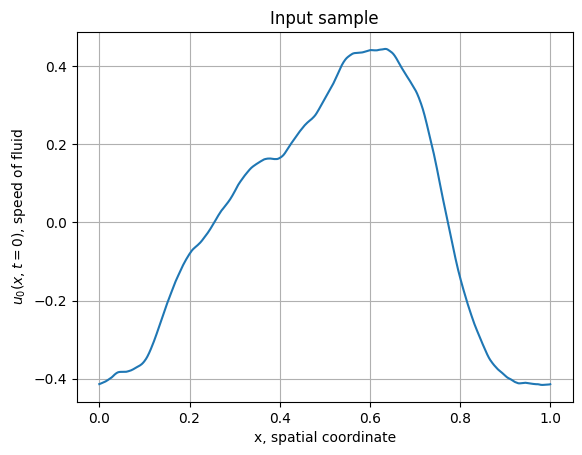

In [13]:
fig, ax = plt.subplots()
x = np.linspace(0, 1, 1024)

ax.plot(x, x_data[idx])
ax.set(xlabel='x, spatial coordinate',
       ylabel=r"$u_{0}(x, t=0)$, speed of fluid",
       title='Input sample')
ax.grid()

plt.show()

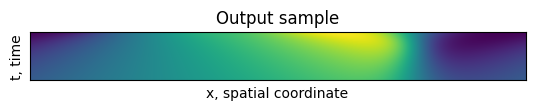

In [14]:
fig, ax = plt.subplots()

ax.imshow(y_data[idx])
ax.set(xticks=[], yticks=[], ylabel="t, time", xlabel="x, spatial coordinate",
       title='Output sample')

plt.show()

Задача 1

In [15]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from neuralop.models import FNO2d
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm

In [16]:
X = x_data.float().unsqueeze(1).unsqueeze(1).repeat(1, 1, 101, 1)
Y = y_data.float().unsqueeze(1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([2048, 1, 101, 1024])
Y shape: torch.Size([2048, 1, 101, 1024])


In [17]:
num_samples = X.size(0)
train_size = int(0.8 * num_samples)
indices = torch.randperm(num_samples)

train_idx, val_idx = indices[:train_size], indices[train_size:]
x_train, y_train = X[train_idx], Y[train_idx]
x_val, y_val = X[val_idx], Y[val_idx]

In [18]:
BATCH_SIZE = 16

train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(x_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
param_grid = {
    'num_layers': [2, 4],
    'n_modes_height': [8, 12],
    'n_modes_width': [8, 12],
    'hidden_channels': [32],
}

In [20]:
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_val_loss = float('inf')
best_train_losses, best_val_losses = [], []
best_params = None

for params in ParameterGrid(param_grid):
    print(f"Testing parameters: {params}")

    model = FNO2d(
        in_channels=1,
        out_channels=1,
        n_modes_height=params['n_modes_height'],
        n_modes_width=params['n_modes_width'],
        hidden_channels=params['hidden_channels'],
        n_layers=params['num_layers']
    ).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"):
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            predictions = model(X_batch).squeeze(1)
            target = y_batch.squeeze(1)
            loss = loss_fn(predictions, target)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        epoch_train_loss /= len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                predictions = model(X_batch).squeeze(1)
                loss = loss_fn(predictions, y_batch.squeeze(1))
                epoch_val_loss += loss.item()

        epoch_val_loss /= len(val_loader)
        val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_train_losses = train_losses
        best_val_losses = val_losses
        best_params = params

    print("\n" + "-" * 75 + "\n")

Testing parameters: {'hidden_channels': 32, 'n_modes_height': 8, 'n_modes_width': 8, 'num_layers': 2}


Epoch 1/5:   0%|          | 0/103 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  return self.__class__(self.tensor[indices])
/usr/local/lib/python3.12/dist-packages/neuralop/layers/spectral_convolution.py:468: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/au

Epoch  1/5 | Train Loss: 0.015379 | Val Loss: 0.005308


Epoch 2/5: 100%|██████████| 103/103 [00:37<00:00,  2.71it/s]


Epoch  2/5 | Train Loss: 0.002278 | Val Loss: 0.000947


...

Epoch  3/5 | Train Loss: 0.000287 | Val Loss: 0.000101


Epoch 4/5: 100%|██████████| 103/103 [01:09<00:00,  1.49it/s]


Epoch  4/5 | Train Loss: 0.000058 | Val Loss: 0.000040


Epoch 5/5: 100%|██████████| 103/103 [01:09<00:00,  1.49it/s]


Epoch  5/5 | Train Loss: 0.000031 | Val Loss: 0.000029

---------------------------------------------------------------------------



Best parameters: {'hidden_channels': 32, 'n_modes_height': 12, 'n_modes_width': 12, 'num_layers': 4}
Best validation Loss: 0.000029


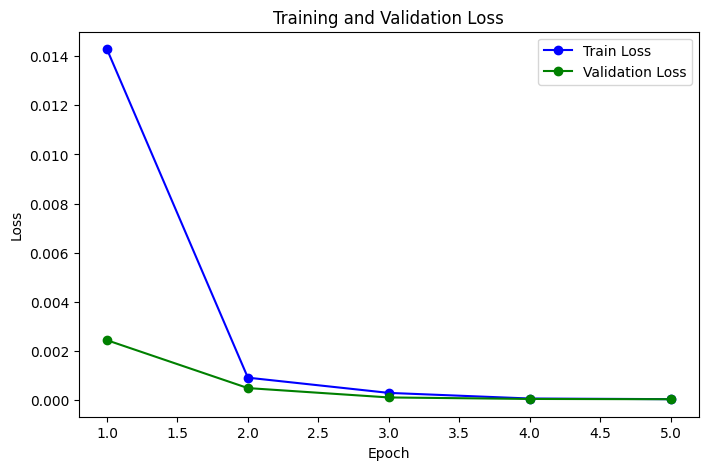

In [21]:
print(f"Best parameters: {best_params}")
print(f"Best validation Loss: {best_val_loss:.6f}")

epochs = range(1, len(best_train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, best_train_losses, label="Train Loss", marker="o", color="b")
plt.plot(epochs, best_val_losses, label="Validation Loss", marker="o", color="g")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

Вывод: минимальная ошибка на сетке получилась при параметрах 'hidden_channels': 32, 'n_modes_height': 12, 'n_modes_width': 12, 'num_layers': 4. Модель дает хороший лосс за 5 эпох на всех вариантах. При количестве слоев 4 лосс еще меньше, чем при 2.

Задача 2

In [22]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]

        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        x_out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x_out

In [23]:
class FNO2dNew(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, width, num_layers):
        super(FNO2dNew, self).__init__()

        self.width = width
        self.modes1 = modes1
        self.modes2 = modes2
        self.num_layers = num_layers

        self.fc0 = nn.Linear(in_channels, self.width)

        self.spectral_layers = nn.ModuleList([
            SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
            for _ in range(self.num_layers)
        ])

        self.conv_layers = nn.ModuleList([
            nn.Conv2d(self.width, self.width, 1)
            for _ in range(self.num_layers)
        ])

        self.fc1 = nn.Linear(self.width, 64)
        self.fc2 = nn.Linear(64, out_channels)

        self.activation = nn.ReLU()

    def fourier_layer(self, x, spectral_layer, conv_layer):
        return self.activation(spectral_layer(x) + conv_layer(x))

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        for i in range(self.num_layers):
            x = self.fourier_layer(x, self.spectral_layers[i], self.conv_layers[i])

        x = x.permute(0, 2, 3, 1)

        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)

In [26]:
import pytorch_lightning as pl
class FNO2dLightning(pl.LightningModule):
    def __init__(self, network, lr=1e-3):
        super(FNO2dLightning, self).__init__()
        self.network = network
        self.lr = lr
        self.loss_fn = nn.MSELoss()

    def configure_optimizers(self):
        return optim.Adam(self.network.parameters(), lr=self.lr)

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        if y_pred.dim() == 3:
            y_pred = y_pred.unsqueeze(1)
        loss = self.loss_fn(y_pred, y)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        if y_pred.dim() == 3:
            y_pred = y_pred.unsqueeze(1)
        loss = self.loss_fn(y_pred, y)
        self.log("val_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        return loss

In [27]:
R = [2, 4, 8, 12, 16]
width = 32
num_layers = 4
val_losses = []

for r in R:
    model = FNO2dNew(
        in_channels=1,
        out_channels=1,
        modes1=r,
        modes2=r,
        width=width,
        num_layers=num_layers
    )
    lightning_model = FNO2dLightning(model)
    trainer = pl.Trainer(max_epochs=5, accelerator='gpu')
    trainer.fit(lightning_model, train_loader, val_loader)
    val_loss = trainer.callback_metrics["val_loss"].item()
    val_losses.append(val_loss)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network │ FNO2dNew │ 39.2 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss  │      0 │ train │     0 │
└───┴─────────┴──────────┴────────┴───────┴───────┘

Trainable params: 39.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network │ FNO2dNew │  2.1 M │ train │     0 │
│ 1 │ loss_fn │ MSELoss  │      0 │ train │     0 │
└───┴─────────┴──────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


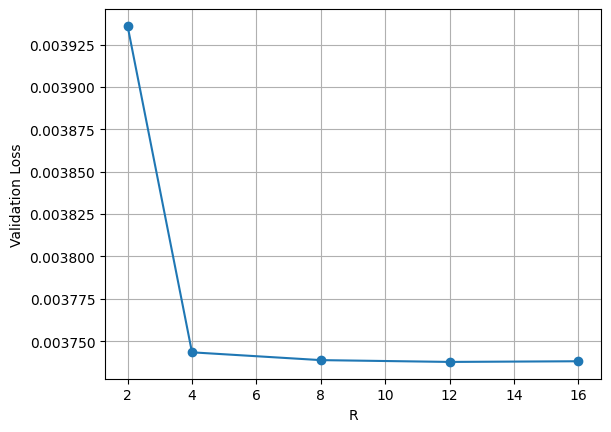

In [28]:
import matplotlib.pyplot as plt
plt.plot(R, val_losses, marker="o", linestyle="-")
plt.xlabel("R")
plt.ylabel("Validation Loss")
plt.grid()
plt.show()

Вывод: При увеличении числа гармоник от 2 до 16 лосс падает. Причем при увеличении с 2 до 4 падает сильно, а дальше уже слабее, потому что в модели мы берем первые н гармоник. Первые из них более информативны, а дальше уже не так сильно.